In [2]:
# ============================================
# W3D5: Hyperparameter Tuning - GridSearchCV
# ============================================

# Import required libraries
import numpy as np
import pandas as pd

# Dataset
from sklearn.datasets import load_iris

# Data splitting
from sklearn.model_selection import train_test_split

# Machine Learning model
from sklearn.svm import SVC

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Visualization
import matplotlib.pyplot as plt

In [3]:
# Load the Iris dataset
iris = load_iris()

# Store features and target
X = iris.data
y = iris.target

# Display dataset information
print("Dataset loaded successfully!")
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature names:")
print(iris.feature_names)

print("\nTarget names:")
print(iris.target_names)

Dataset loaded successfully!
Feature shape: (150, 4)
Target shape: (150,)

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target names:
['setosa' 'versicolor' 'virginica']


In [4]:
# Create a DataFrame for better understanding of the data
df = pd.DataFrame(X, columns=iris.feature_names)

# Add target column
df["target"] = y

# Display first 10 rows
print("First 10 rows of the dataset:")
display(df.head(10))

First 10 rows of the dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


In [5]:
# Check dataset information
print("Dataset Information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDataset shape:")
print(df.shape)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

Dataset shape:
(150, 5)


In [6]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training data shape: (120, 4)
Testing data shape: (30, 4)
Training target shape: (120,)
Testing target shape: (30,)


In [7]:
# Create the Support Vector Machine model
svm_model = SVC()

print("SVM model created successfully!")
print(svm_model)

SVM model created successfully!
SVC()


In [8]:
# Define different hyperparameter values
# GridSearchCV will test every possible combination

param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

print("Hyperparameter grid:")
print(param_grid)

Hyperparameter grid:
{'C': [0.1, 1, 10, 100], 'kernel': ['linear', 'rbf'], 'gamma': ['scale', 'auto']}


In [9]:
# Create GridSearchCV
grid_search = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

# Train GridSearchCV
grid_search.fit(X_train, y_train)

print("\nGridSearchCV completed successfully!")

Fitting 5 folds for each of 16 candidates, totalling 80 fits

GridSearchCV completed successfully!


In [10]:
# Display the best hyperparameters
print("======================================")
print("BEST HYPERPARAMETERS")
print("======================================")

print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)

BEST HYPERPARAMETERS
{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}

Best Cross-Validation Accuracy:
0.9833333333333334


In [11]:
# Get the best SVM model found by GridSearchCV
best_svm_model = grid_search.best_estimator_

print("Best SVM Model:")
print(best_svm_model)

Best SVM Model:
SVC(C=0.1, kernel='linear')


In [12]:
# Predict the test dataset
y_pred = best_svm_model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


In [13]:
# Calculate test accuracy
accuracy = accuracy_score(y_test, y_pred)

print("======================================")
print("MODEL PERFORMANCE")
print("======================================")

print("Test Accuracy:", accuracy)
print("Test Accuracy (%):", accuracy * 100)

MODEL PERFORMANCE
Test Accuracy: 0.9666666666666667
Test Accuracy (%): 96.66666666666667


In [14]:
# Display detailed classification report
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [15]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


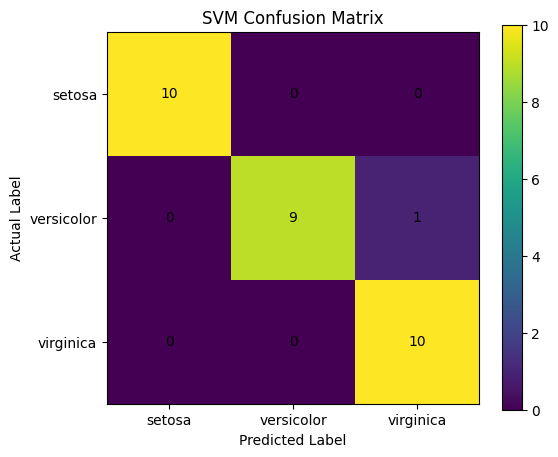

In [16]:

# Plot confusion matrix
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    range(len(iris.target_names)),
    iris.target_names
)

plt.yticks(
    range(len(iris.target_names)),
    iris.target_names
)

# Display values inside the matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

In [17]:
# Convert GridSearchCV results into a DataFrame
results = pd.DataFrame(grid_search.cv_results_)

# Select useful columns
results = results[
    [
        "param_C",
        "param_kernel",
        "param_gamma",
        "mean_test_score",
        "rank_test_score"
    ]
]

# Sort by rank
results = results.sort_values("rank_test_score")

print("GridSearchCV Results:")
display(results)

GridSearchCV Results:


,param_C,param_kernel,param_gamma,mean_test_score,rank_test_score
0,0.1,linear,scale,0.983333,1
2,0.1,linear,auto,0.983333,1
6,1.0,linear,auto,0.983333,1
4,1.0,linear,scale,0.983333,1
7,1.0,rbf,auto,0.983333,1
9,10.0,rbf,scale,0.983333,1
5,1.0,rbf,scale,0.975000,7
8,10.0,linear,scale,0.966667,8
10,10.0,linear,auto,0.966667,8
11,10.0,rbf,auto,0.966667,8


In [18]:
# Display final summary
print("==========================================")
print("FINAL SUMMARY")
print("==========================================")

print("Algorithm: Support Vector Machine (SVM)")
print("Tuning Method: GridSearchCV")
print("Cross-Validation: 5-fold")

print("\nBest Parameters:")
for parameter, value in grid_search.best_params_.items():
    print(f"{parameter}: {value}")

print("\nBest CV Accuracy:",
      round(grid_search.best_score_, 4))

print("Test Accuracy:",
      round(accuracy, 4))

print("Test Accuracy (%):",
      round(accuracy * 100, 2), "%")

FINAL SUMMARY
Algorithm: Support Vector Machine (SVM)
Tuning Method: GridSearchCV
Cross-Validation: 5-fold

Best Parameters:
C: 0.1
gamma: scale
kernel: linear

Best CV Accuracy: 0.9833
Test Accuracy: 0.9667
Test Accuracy (%): 96.67 %
